# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 4. Матричный профиль. Поиск примитивов на его основе.**

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib tk
!chcp 65001
!dir

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Active code page: 65001
 Volume in drive E has no label.
 Volume Serial Number is 7E48-815E

 Directory of e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\04 Matrix profile

07.11.2025  22:23    <DIR>          .
22.11.2025  01:23    <DIR>          ..
28.11.2025  14:17            31 516 04 Matrix profile.ipynb
07.11.2025  22:23    <DIR>          datasets
07.11.2025  22:23    <DIR>          modules
               1 File(s)         31 516 bytes
               4 Dir(s)  400 654 385 152 bytes free


Смените рабочую директорию с помощью команды `chdir()`. Для этого передайте этой команде свой путь до каталога, в котором содержатся материалы четвертой практической работы. После выполнения этой команды все последующие операции с файлами и каталогами будут производиться относительно указанного каталога.

In [3]:
import os

practice_dir_path = 'E:/maga/ryads/pr1/25-Chekrygin-TimeSeriesCourse/practice/04 Matrix profile'
os.chdir(practice_dir_path)

Выполните команды, которые автоматически перезагружают все импортированные модули при их изменении.

Импортируйте библиотеки и модули, необходимые для реализации практической работы 4.

In [4]:
!pip install stumpy

In [5]:
import pandas as pd
import numpy as np
import os
import datetime

from modules.plots import *
from modules.mp import compute_mp
from modules.motifs import top_k_motifs
from modules.discords import top_k_discords
from modules.meter_swapping_detection import *

## **Часть 1.** Матричный профиль. Поиск мотивов и диссонансов.

### **Задача 1.**
Загрузите временной ряд, который содержит данные о почасовом потреблении электроэнергии некоторого итальянского города, снимаемые в течение 3 лет, начиная с 1 января 1995 года.

In [6]:
ts_url = './datasets/part1/italianpowerdemand.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд, используя функцию `plot_ts()` из модуля *plot.py*.

In [7]:
plot_ts(ts, "Input time series")

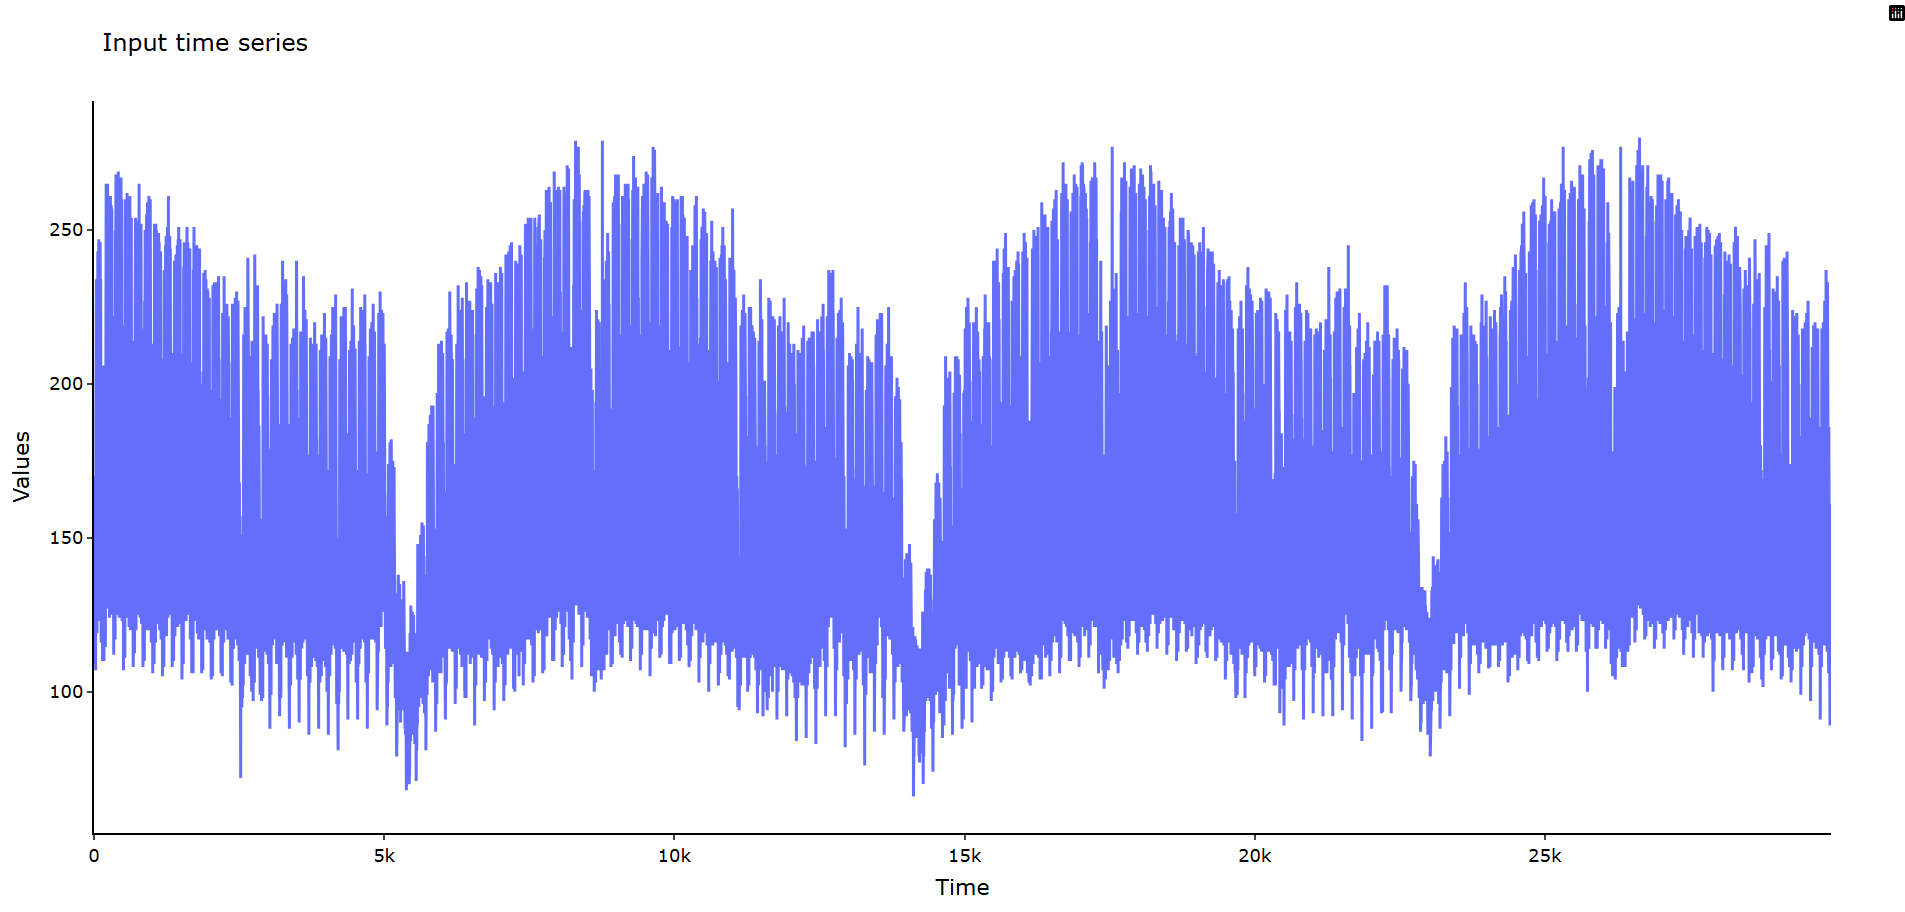

Анализ временных рядов на основе матричного профиля осуществляет библиотека [stumpy](https://stumpy.readthedocs.io/en/latest/index.html). Напишите функцию `compute_mp()` в модуле *mp.py*, которая вычисляет матричный профиль временного ряда на основе выбранной вами функции из библиотеки *stumpy*.

In [8]:
m = 165
excl_zone = int(np.ceil(m / 2))
mp = {}

mp = compute_mp(ts1=ts, m=m)

print("Matrix Profile:", mp['mp'])
print("Matrix Profile Indices:", mp['mpi'])

Matrix Profile: [2.6090936641687352 2.5924180135439157 2.59877638124769 ...
 2.007681867612602 2.020641558173467 2.030675731613809]
Matrix Profile Indices: [ 8761  8762  8763 ... 21195 21196 21197]


Визуализируйте найденный матричный профиль ряда.

In [9]:
plot_ts(mp['mp'], "Matrix Profile")

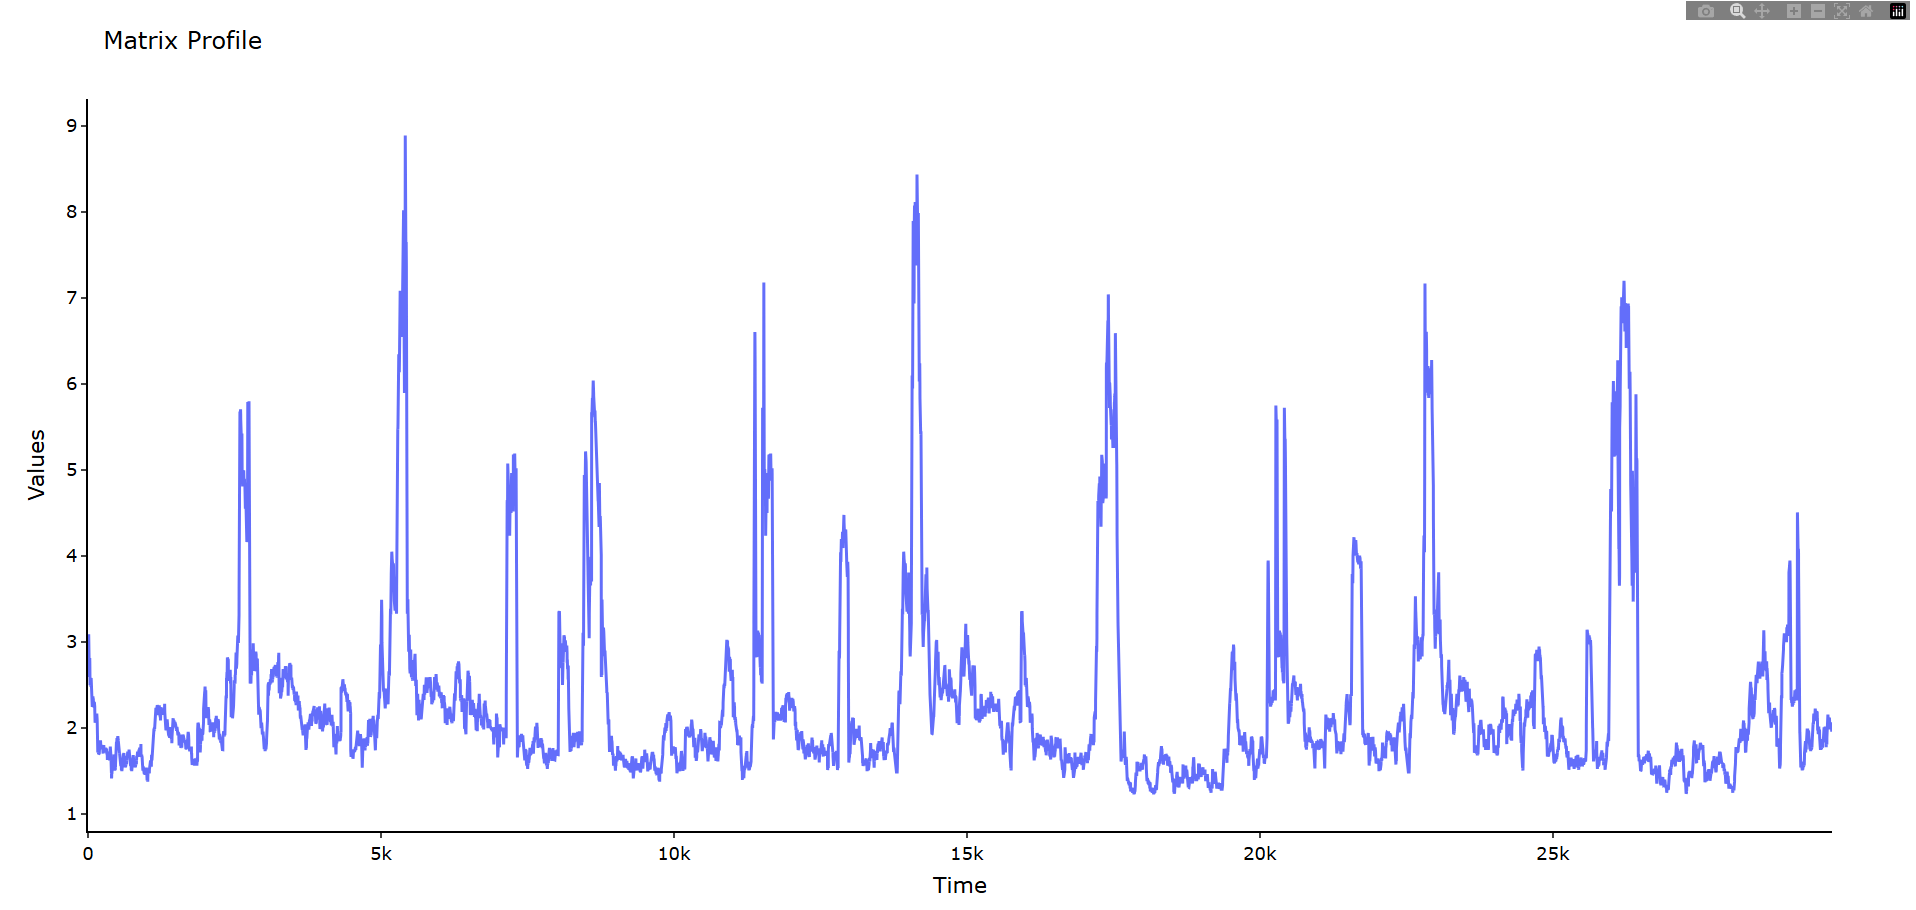

### **Задача 2.**
Выполните поиск top-$k$ мотивов в исходном временном ряде на основе построенного матричного профиля. Для этого реализуйте самостоятельно функцию `top_k_motifs()` в модуле *motifs.py*. Среди найденных мотивов не должно быть тривиальных совпадений, поэтому в `top_k_motifs()` добавьте вызов функции `apply_exclusion_zone()` из модуля *utils.py*.

In [10]:
top_k = 6
motifs = top_k_motifs(matrix_profile=mp, top_k=top_k)

print("Top-6 Motifs Indices:", motifs['indices'])
print("Top-6 Motifs Distances:", motifs['distances'])

Top-6 Motifs Indices: [(np.int64(17852), np.int64(18188)), (np.int64(17853), np.int64(18189)), (np.int64(17858), np.int64(18194)), (np.int64(17859), np.int64(18195)), (np.int64(18539), np.int64(27276)), (np.int64(17857), np.int64(18193))]
Top-6 Motifs Distances: [1.2266251888823085, 1.231976204988157, 1.233121598265018, 1.234827047461622, 1.2356334381445668, 1.2362405888543486]


Выполните визуализацию найденных top-$k$ мотивов с помощью функции `plot_motifs()` из *plots.py*.

In [11]:
plot_motifs(mp, motifs)

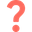
Проанализируйте и изложите содержательный смысл полученных результатов.

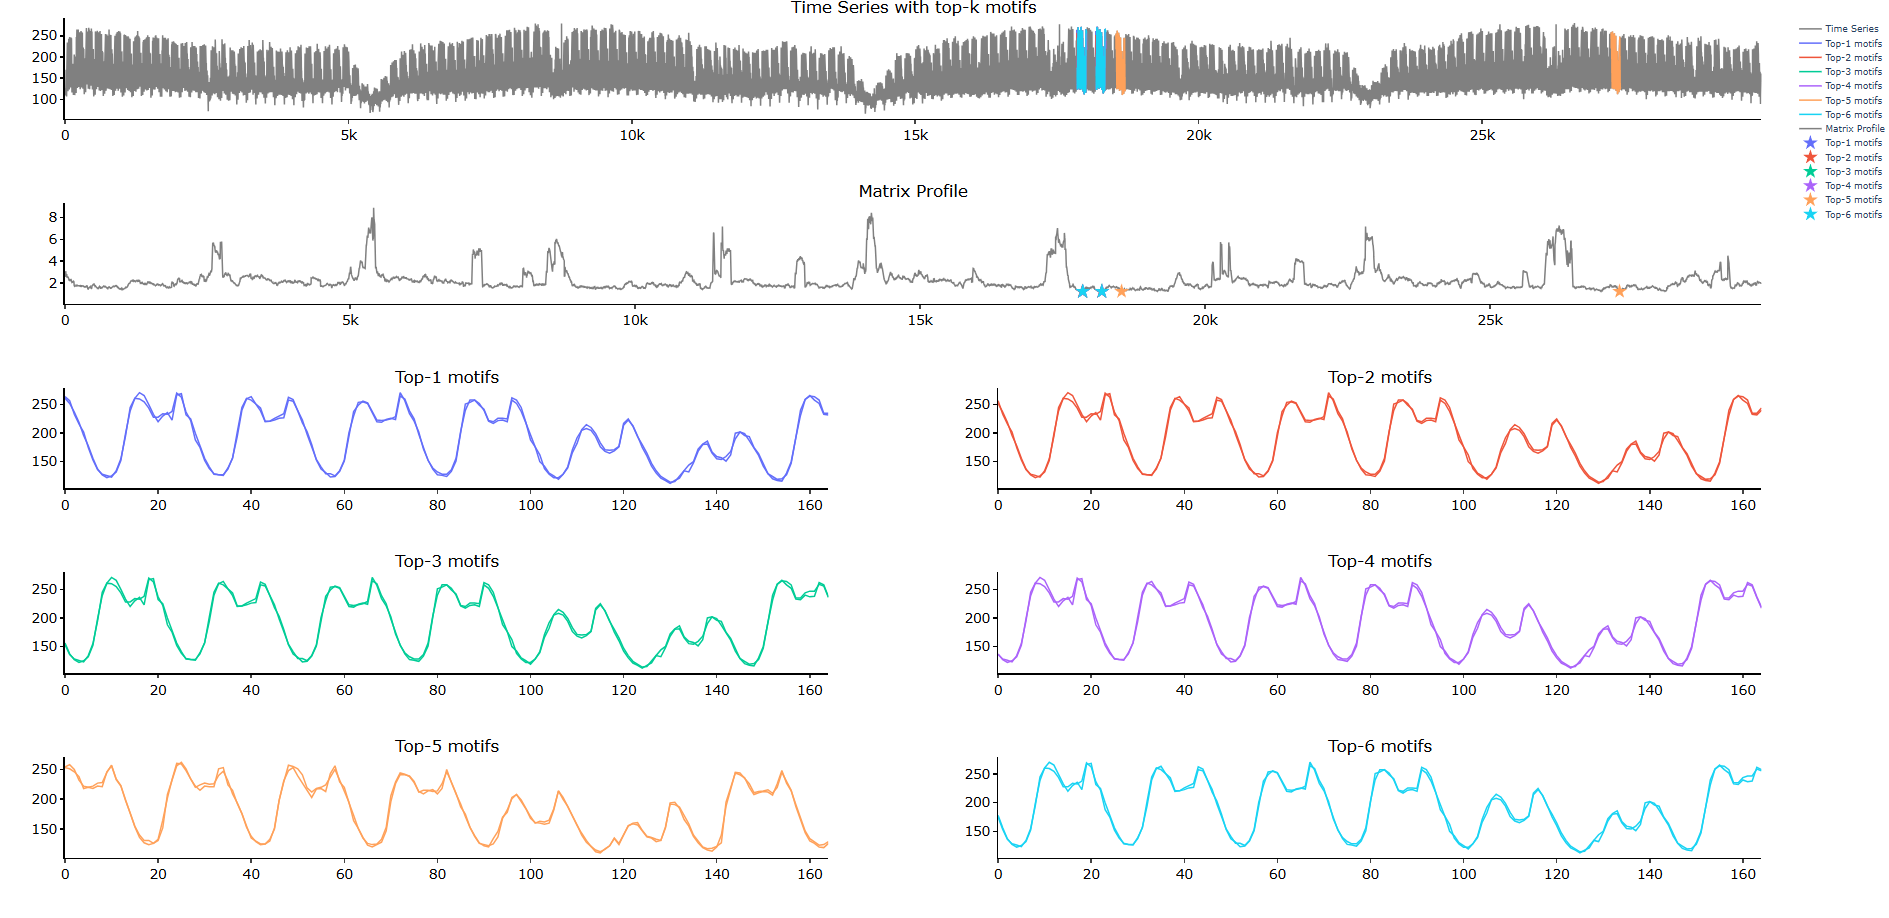

На графике временного ряда видно, что существуют повторяющиеся паттерны, как локально, так и на больших интервалах. Первые четыре пары мотивов находятся близко друг к другу по индексам, что указывает на повторяющиеся формы ряда в коротком временном окне. Пятая пара мотивов расположена далеко друг от друга, что говорит о редком или сезонном повторении паттерна. Расстояния между мотивами невелики, около 1.23–1.24, что подтверждает их высокую схожесть.

### **Задача 3.**
Реализуйте самостоятельно функцию `top_k_discords()` в модуле *discords.py*, предназначенную для поиска top-$k$ диссонансов во временном ряде на основе матричного профиля. Чтобы исключить попадание тривиальных совпадений в результирующее множество диссонансов воспользуйтесь функцией `apply_exclusion_zone()` из модуля *utils.py*.

Загрузите временной ряд *nyc_taxi.csv* из директории *./datasets/part1/*, содежащий данные о среднем числе пассажиров NY такси за осень 2014 года.

In [12]:
ts_url = './datasets/part1/nyc_taxi.csv'

ts = pd.read_csv(ts_url, index_col=0, header=0).squeeze().to_numpy()
plot_ts(ts, "Input time series")

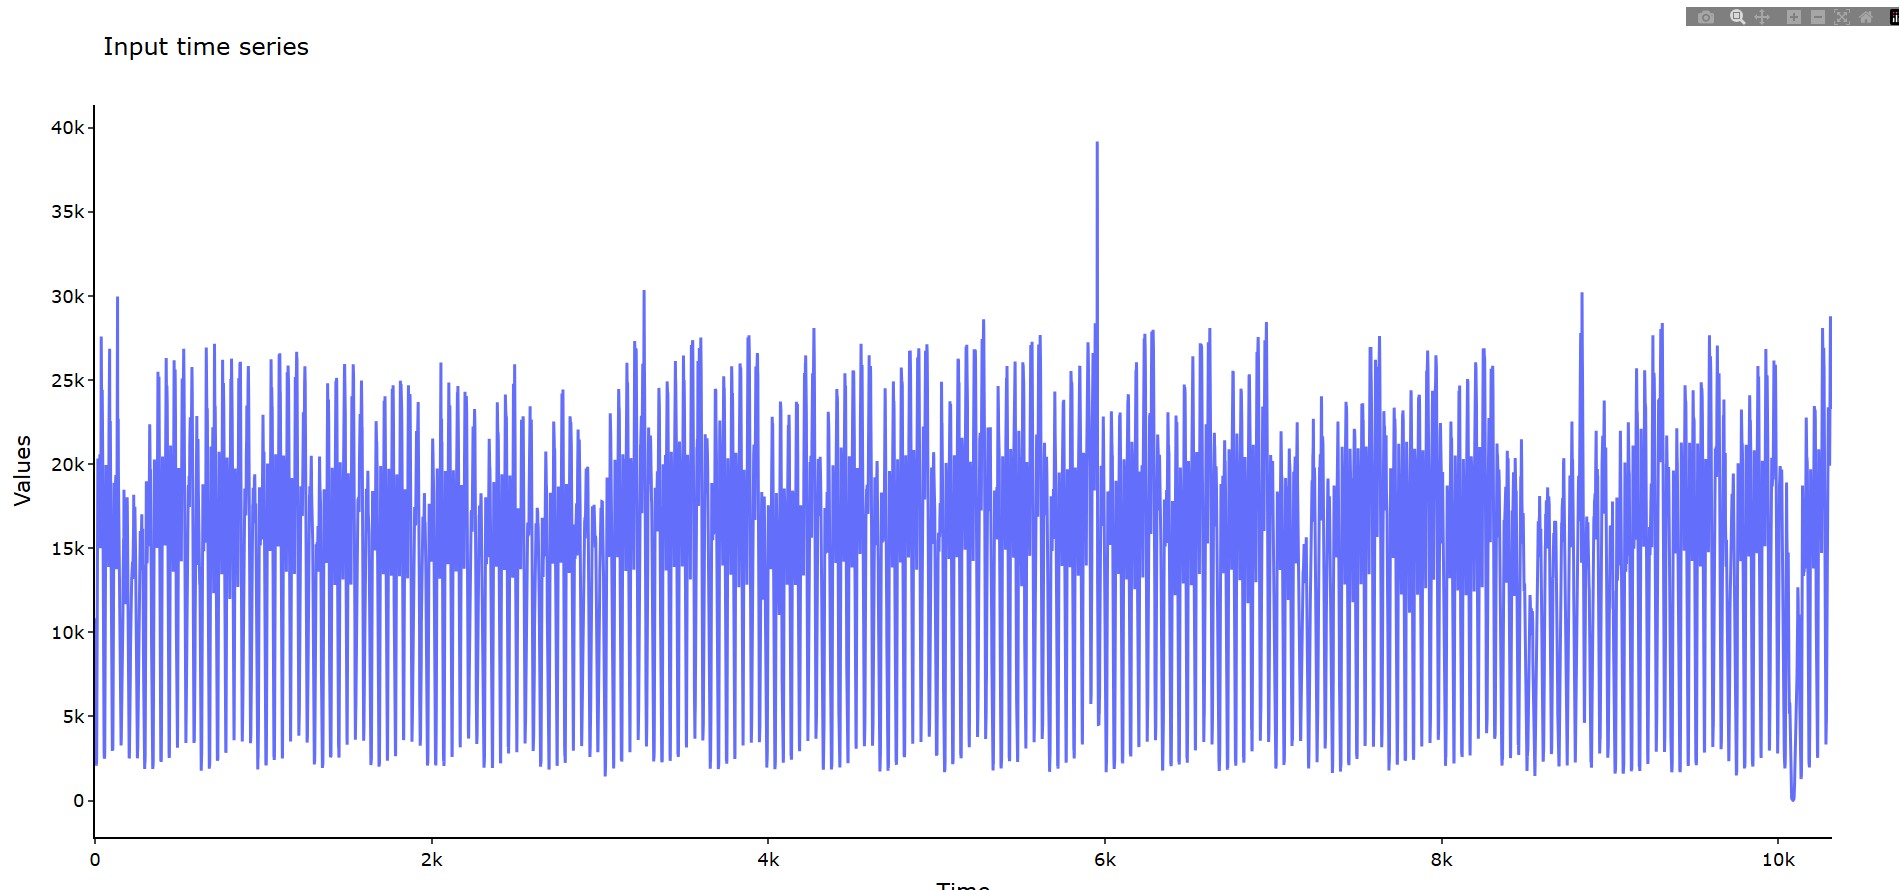

In [28]:
m = 96
excl_zone = int(np.ceil(m / 2))
mp = {}

ts = pd.read_csv(ts_url, index_col=0, header=0).squeeze().to_numpy().astype(np.float64)

mp = compute_mp(ts, m)

print(type(mp))
print(mp)
m = 96
excl_zone = int(np.ceil(m / 2))

<class 'dict'>
{'mp': array([1.67587959, 1.70621488, 1.71714657, ..., 1.2289711 , 1.20828174,
       1.19482127]), 'mpi': array([ 336,  337,  338, ..., 9550, 9551, 9552]), 'm': 96, 'data': {'ts1': array([10844.,  8127.,  6210., ..., 27309., 26591., 26288.]), 'ts2': None}}


In [29]:
top_k = 15
discords = top_k_discords(matrix_profile=mp, excl_zone=excl_zone, top_k=top_k)

print("Top-15 Индексы Дискордов:", discords['indices'])
print("Top-15 Дистанции Дискордов:", discords['distances'])
print("Top-15 Индексы Ближайших Соседей Дискордов:", discords['nn_indices'])

Top-15 Индексы Дискордов: [np.int64(9985), np.int64(10048), np.int64(8784), np.int64(10097), np.int64(8837), np.int64(5868), np.int64(105), np.int64(9651), np.int64(8449), np.int64(5954), np.int64(7107), np.int64(154), np.int64(8396), np.int64(8640), np.int64(2930)]
Top-15 Дистанции Дискордов: [np.float64(7.676119373289262), np.float64(7.528591080691671), np.float64(6.073551099449276), np.float64(5.111043244960352), np.float64(4.492294012659743), np.float64(4.241043745808613), np.float64(4.165698256274182), np.float64(3.947103465362411), np.float64(3.7361108831967065), np.float64(3.706803612131884), np.float64(3.6988843800360964), np.float64(3.4414770204510625), np.float64(3.360238569108185), np.float64(3.2855364012281094), np.float64(3.1770979488518285)]
Top-15 Индексы Ближайших Соседей Дискордов: [9650, 8469, 9263, 257, 5618, 6204, 7112, 8307, 7104, 5282, 8452, 7210, 8348, 7295, 194]


Выполните визуализацию найденных top-$k$ диссонансов.

In [30]:
plot_discords(mp, discords)

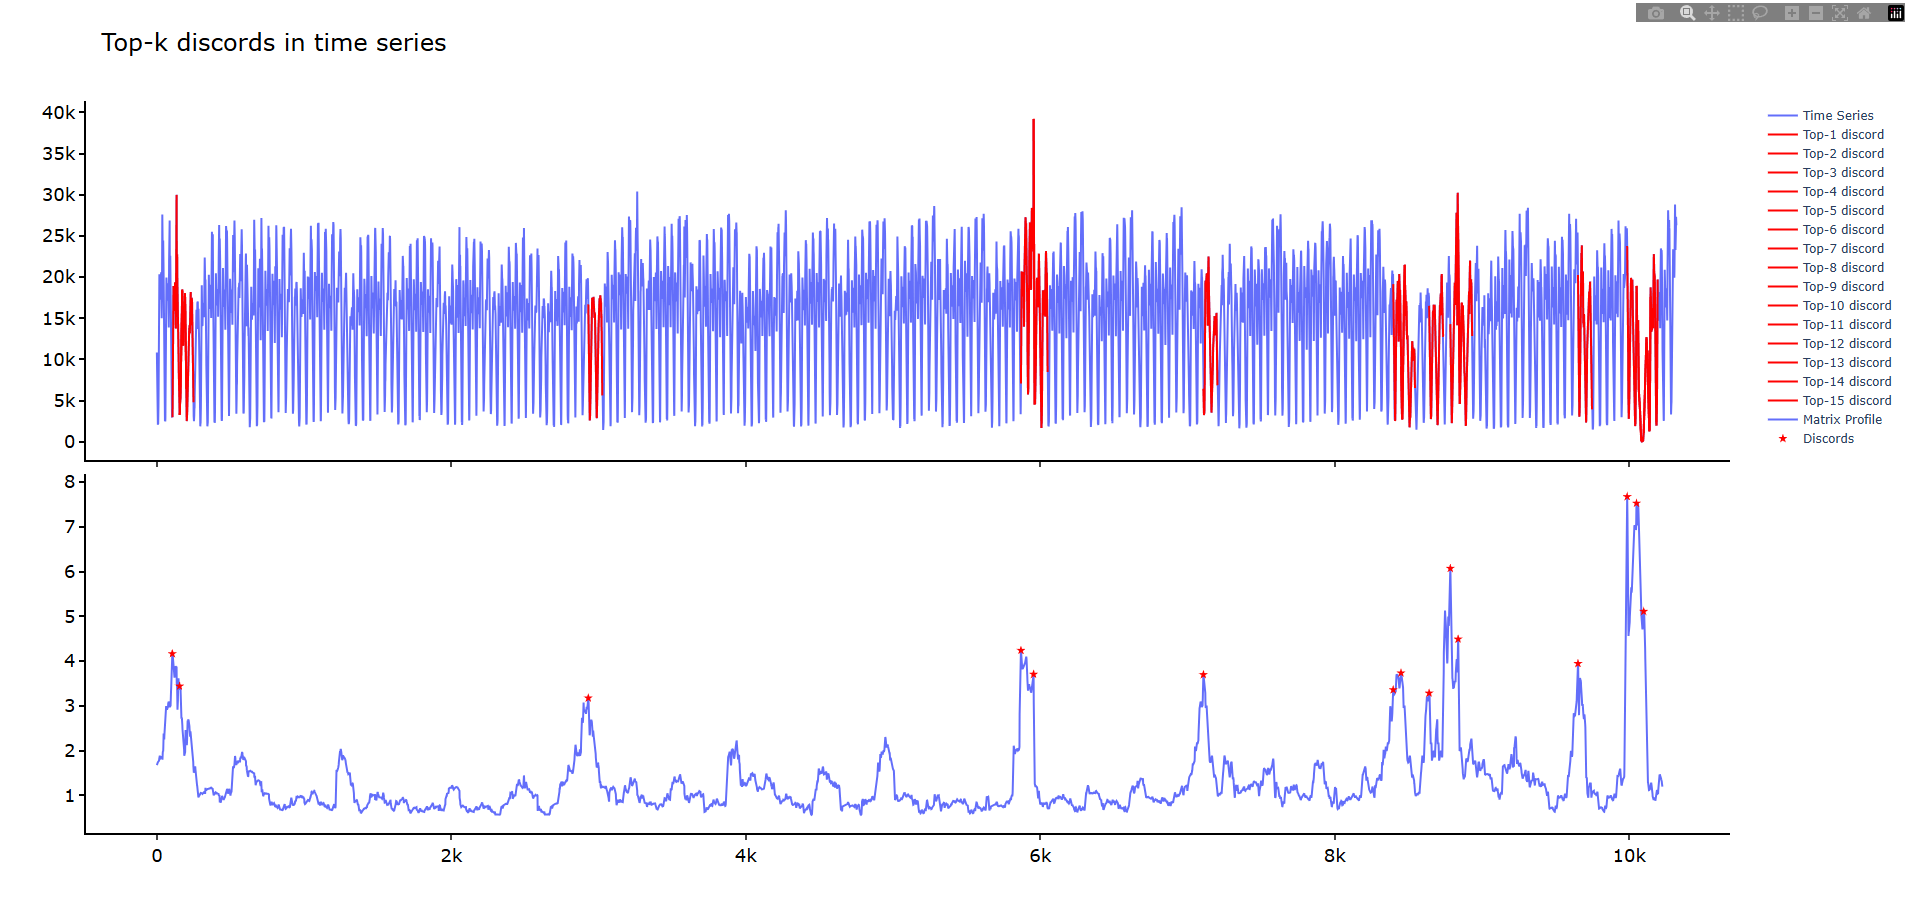

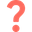
Проанализируйте и изложите содержательный смысл полученных результатов.

В результате анализа данных методом выявления дискордов было определено 15 ключевых сегментов, резко отличающихся от основной массы данных. Наибольшей аномальностью выделяются сегменты с индексами 9985, 10048 и 8784, с дистанциями 7.676, 7.529 и 6.074 соответственно, что указывает на их значительное отличие от остальных данных. Остальные дискорды имеют более умеренные значения дистанций, постепенно уменьшающиеся до 3.177 у сегмента с индексом 2930.

## **Часть 2.** Сегментация повторяющихся активностей.

### **Задача 4.**

Загрузите временной ряд PAMAP *pamap.csv* из директории *./datasets/part2/*, представляющий собой показания закрепленного на человеке виброакселерометра. Данный ряд включает показания, снятые при выполнении человеком трех видов физической активности: ходьба, подъем по лестнице и спуск по лестнице. Необходимо сегментировать временной ряд на основе его матричного профиля для определения того, когда человек шел и когда поднимался/спускался. Поскольку подъем и спуск по лестнице – это схожие действия, поэтому будем считать, что это одна активность.  

In [31]:
ts_url = './datasets/part2/pamap.csv'

ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy()

Визуализируйте временной ряд PAMAP.

In [32]:
plot_ts(ts, "Input time series")

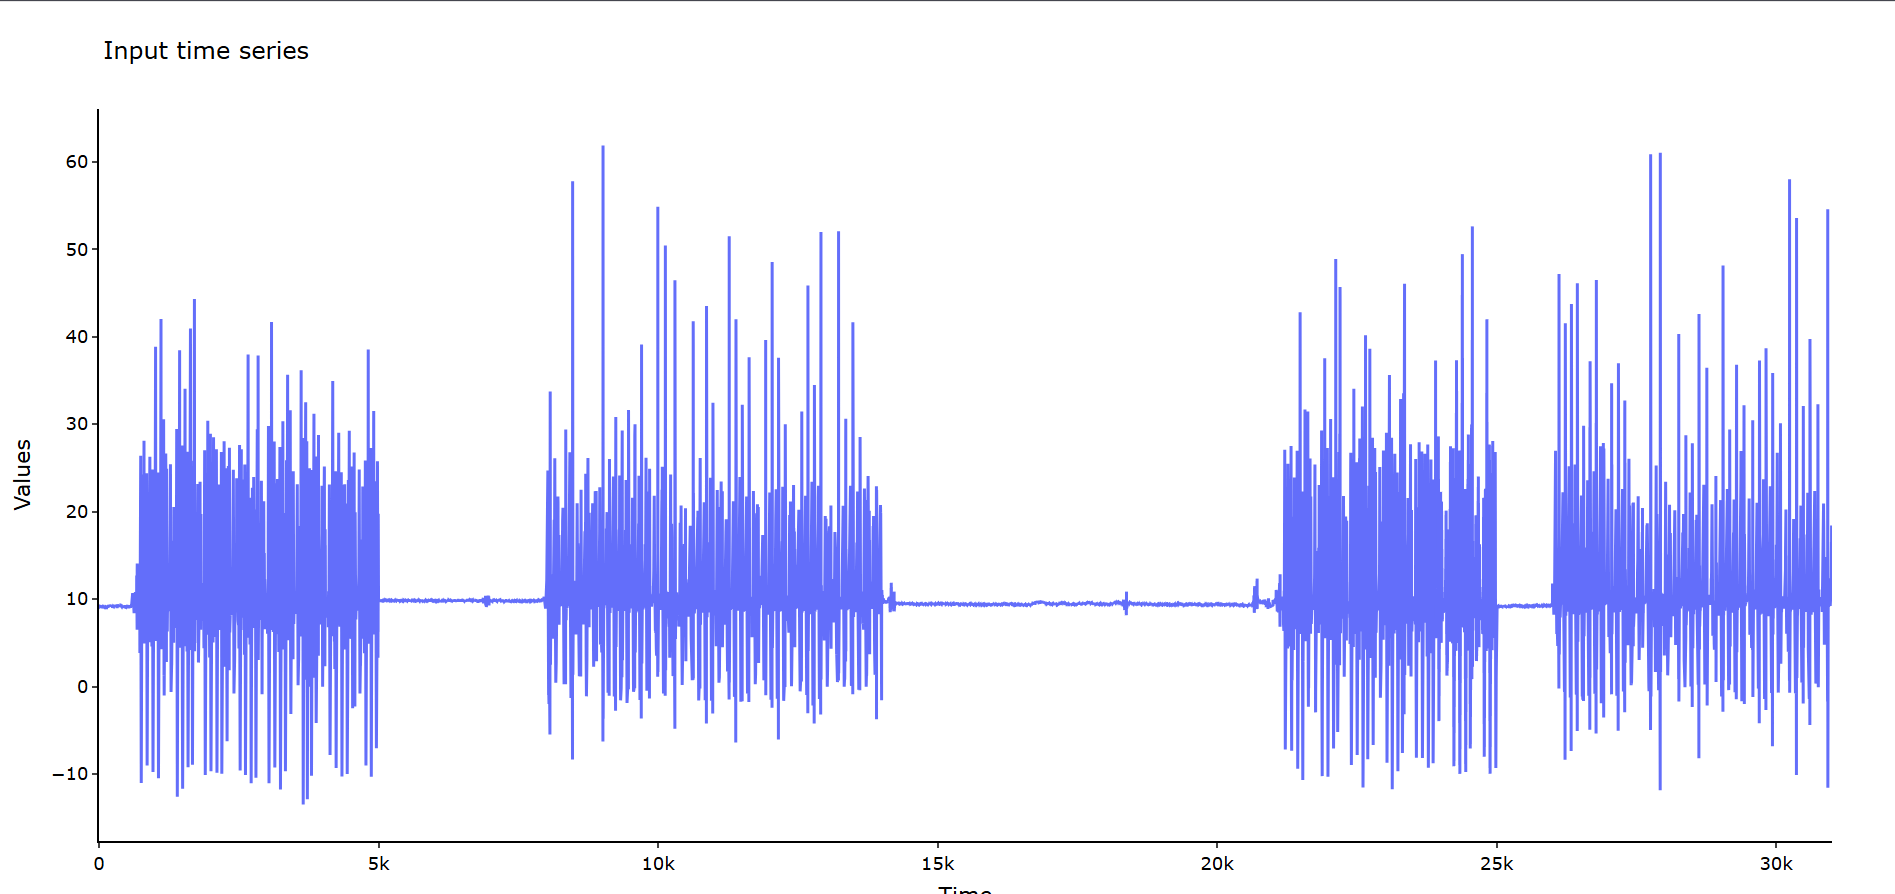

Найдите и визуализируйте матричный профиль временного ряда.

In [33]:
m = 100
excl_zone = m
mp = {}

mp = compute_mp(ts, m)

In [34]:
plot_ts(mp['mp'], "Matrix Profile")

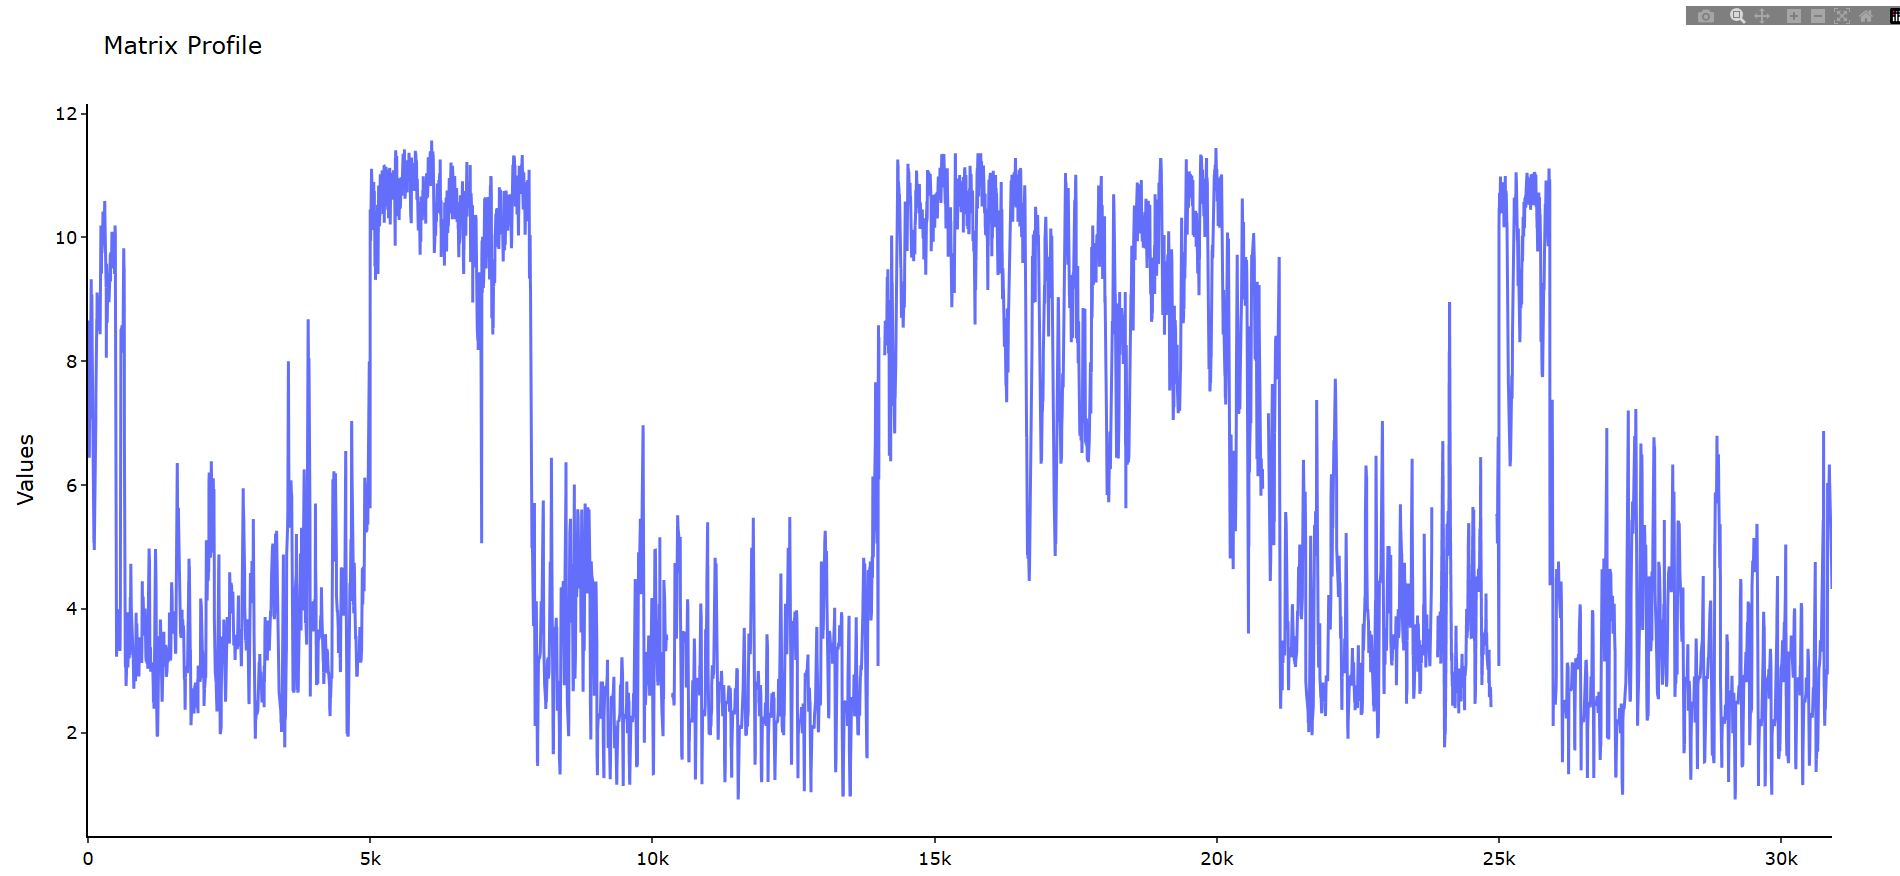

Вычислите порог по формуле, которая представлена в презентации [04 Matrix profile.pdf](https://github.com/mzym/TimeSeriesCourse/blob/main/slides/04%20Matrix%20profile.pdf).

In [66]:
import numpy as np
import pandas as pd
import stumpy

ts_url = './datasets/part2/pamap.csv'
ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy(dtype=float)

m = 100

mp = stumpy.stump(ts, m=m)

MP = mp[:, 0].astype(float)

MP = np.where(np.isfinite(MP), MP, np.nan)
MP_clean = MP[~np.isnan(MP)]

k = 3
threshold = np.mean(MP_clean) + k * np.std(MP_clean)

top_discords_idx = np.argsort(MP_clean)[-15:][::-1]
top_discords_dist = MP_clean[top_discords_idx]

print("Threshold (mean + 3*std):", threshold)
print("Top-15 дискордов (индексы):", top_discords_idx)
print("Top-15 дискордов (дистанции):", top_discords_dist)


Threshold (mean + 3*std): 15.404752886633537
Top-15 дискордов (индексы): [ 6089  6090  6086  6092 19785  6091  5607  5451  6088  5450  5800  6064
  6111  6093  5608]
Top-15 дискордов (дистанции): [11.56341516 11.51366307 11.49901374 11.47334998 11.44474643 11.42155295
 11.42152039 11.40670338 11.40595716 11.40321164 11.39946245 11.39030664
 11.38752544 11.38202592 11.37468323]


Выполните визуализацию результатов сегментации повторяющихся активностей.

In [67]:
import numpy as np
import pandas as pd
import stumpy
from modules.plots import plot_segmentation

ts_url = './datasets/part2/pamap.csv'
ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy(dtype=float)

m = 100

mp_stumpy = stumpy.stump(ts, m=m)
MP = mp_stumpy[:, 0].astype(float)

MP = np.where(np.isfinite(MP), MP, np.nan)
MP_clean = MP[~np.isnan(MP)]

k = 3
threshold = np.mean(MP_clean) + k * np.std(MP_clean)

mp_dict = {
    'data': {
        'ts1': ts
    },
    'mp': MP
}

plot_segmentation(mp_dict, threshold)


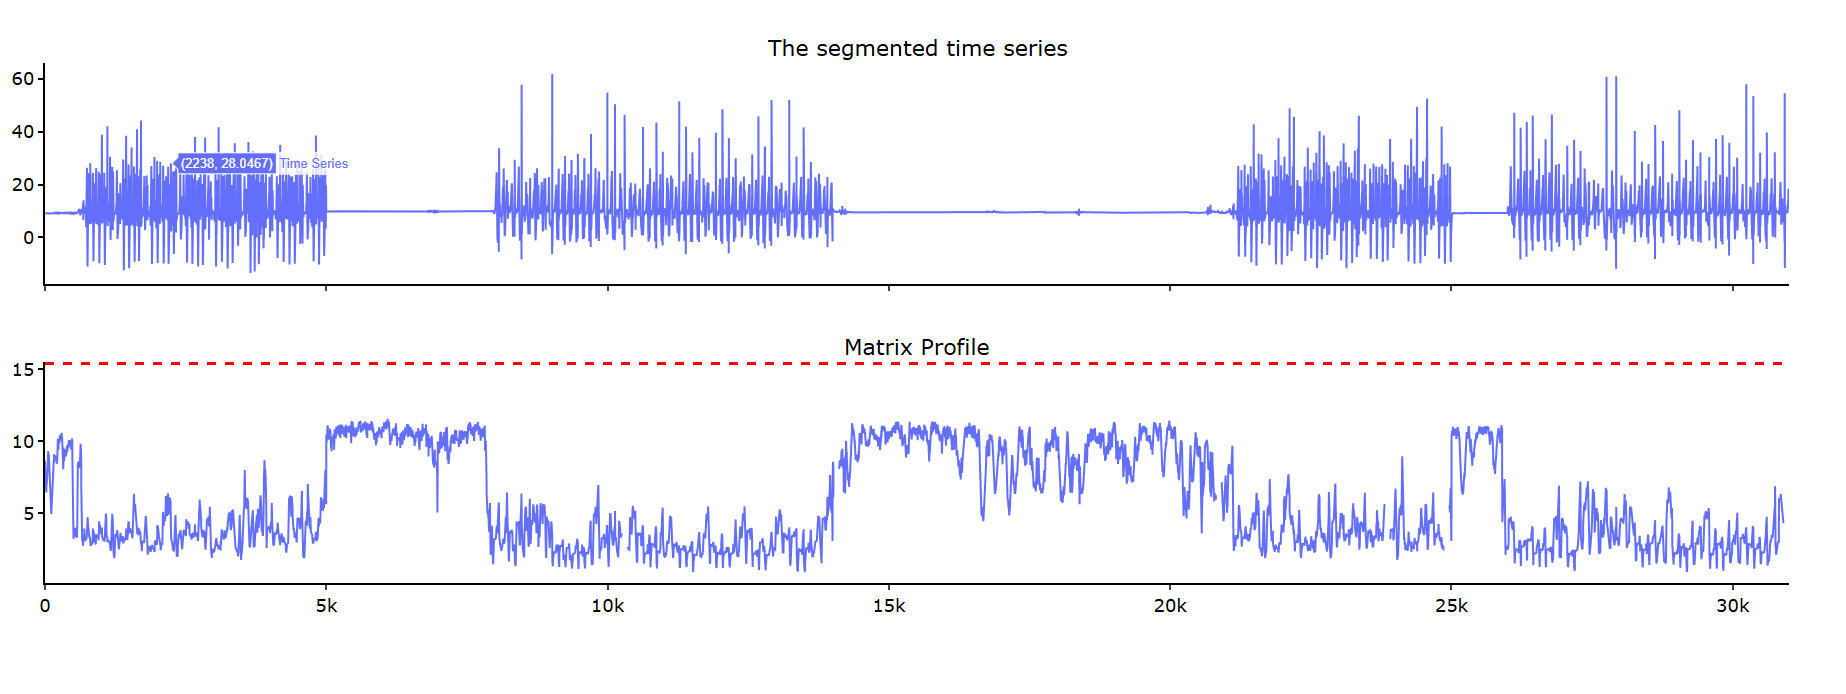

Загрузите истинную разметку временного ряда PAMAP *pamap_labels.csv*, где 0 означает ходьбу, 1 – подъем по лестнице, 2 – спуск с лестницы. Вычислите точность по метрике accuracy, сравнив полученные результаты по основе матричного профиля с истинной разметкой.

In [45]:
labels_url = './datasets/part2/pamap_labels.csv'

labels = pd.read_csv(labels_url, header=None).squeeze().to_numpy()

In [68]:
import numpy as np
import pandas as pd
import stumpy
from sklearn.metrics import accuracy_score

ts_url = './datasets/part2/pamap.csv'
ts = pd.read_csv(ts_url, header=None).squeeze().to_numpy(dtype=float)

labels_url = './datasets/part2/pamap_labels.csv'
true_labels = pd.read_csv(labels_url, header=None).squeeze().to_numpy()

m = 100
mp = stumpy.stump(ts, m=m)
MP = mp[:, 0].astype(float)
MP = np.where(np.isfinite(MP), MP, np.nan)
MP_clean = MP[~np.isnan(MP)]

k = 3
threshold = np.mean(MP_clean) + k * np.std(MP_clean)

top_discords_idx = np.argsort(MP_clean)[-15:][::-1]
pred_labels = np.zeros_like(true_labels)
pred_labels[top_discords_idx] = 1

accuracy = accuracy_score(true_labels, pred_labels)
print(accuracy)


0.35435483870967743


## **Чaсть 3.** Casy Study: Раскрытие краж электричества подменой счетчиков (meter-swapping detection).


### **Задача 5.**

Рассмотрим практическое применение использования матричного профиля для решения задачи, связанной с раскрытием краж электричества путем подмены счетчиков.

Загрузите временные ряды из директории *./datasets/part3/*, которые были выбраны случайным образом из набора данных (House 1, 2, 3, 4 и 11), содержащего данные потребления электроэнергии 20 жилых домов в Великобритании с 1 января по 23 декабря 2014 года.

In [ ]:
path = './datasets/part3/'

house_idx = [1, 2, 3, 4, 11]

filenames = [f"House{i}.csv" for i in house_idx]

consumptions = {}
for house in filenames:
    consumptions[house[:-4]] = pd.read_csv(os.path.join(path, house), header=None, index_col=0)
    consumptions[house[:-4]].index = pd.to_datetime(consumptions[house[:-4]].index, dayfirst=True)

Далее смоделируем событие замены счетчика. Для этого каждый временной ряд разделим на две части: "Head" (до 1 октября) и "Tail" (после 1 октября). После чего выберем случайным образом 2 временных ряда (например, House1 и House11) и поменяем местами их "Tail" части.

In [ ]:
cutoff = pd.to_datetime('2014-10-01')
heads, tails = heads_tails(consumptions, cutoff, house_idx)

#swap Heads and Tails of 1 and 11
swap1, swap2 = 1, 11
consumptions[f'House{swap1}'] = heads[f'H_{swap1}'].append(tails[f'T_{swap2}'])
consumptions[f'House{swap2}'] = heads[f'H_{swap2}'].append(tails[f'T_{swap1}'])
heads, tails = heads_tails(consumptions, cutoff, house_idx)

Визуализируйте исходные временные ряды и параллельную оси OY прямую, которая делит временные ряды на "Head" и "Tail" части.

In [ ]:
plot_consumptions_ts(consumptions, cutoff, house_idx)

Чтобы найти переставленную пару временных рядов, выполним следующее. Сначала составим временные ряды $H_i$ из всевозможных комбинаций "Head" и "Tail" частей исходных временных рядов $T_K$, где $1 \leq i \leq |T|^2$, $1 \leq K \leq |T|$. В нашем случае, $|T| = 5$.  Далее среди них найдем такую пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$. Минимальная оценка $swap\_score$ для пары рядов $(H_i, H_j)$ вычисляется следующим образом:

\begin{equation}
swap\_score(i,j) = \frac{\min{(Head_{H_i} \bowtie Tail_{H_j})}}{\min{(Head_{H_i} \bowtie Tail_{H_i})}+eps},
\end{equation}

где $\bowtie$ – операция нахождения матричного профиля между двумя временными рядами. Матричный профиль между двумя временными рядами содержит расстояния между всеми подпоследовательностями первого временного ряда и их ближайшими соседями, которые являются подпоследовательностями второго временного ряда.

Добавьте в функцию `compute_mp()` в модуле *mp.py* поддежку вычисления матричного профиля между двумя различными временными рядами и найдите пару временных рядов $(H_i, H_j)$, которая имеет минимальную оценку $swap\_score$ среди всех пар.

In [ ]:
m = 24 * 4

min_score = meter_swapping_detection(heads, tails, house_idx, m)

In [ ]:
min_i, min_j, mp_j = min_score['i'], min_score['j'], min_score['mp_j']
print(f'Time series with minimum score is (H_{min_i}, T_{min_j}).')

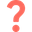
Проанализируйте и изложите содержательный смысл полученных результатов.

*# WRITE YOUR ANSWER*